# AG-HYPOPT · Trial 23

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-two trials are registered; cell 2 reports `phase = trials` (22/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074, found two rounds ago; the previous best was trial_08 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** `lr_mu=0.1669`, `mu_anneal=0.3455` (travel 0.138), `lr_gamma=0.4716`, `gamma_anneal=0.4723` (balanced gamma). 0 div.
- **trial_22 (0.1095):** travel 0.137, near-neighbour of the best; 0 div.
- **trial_08 (0.1099), trial_15 (0.1103), trial_16 (0.1112), trial_12 (0.1115), trial_18 (0.1121):** travels 0.134 / 0.127 / 0.128 / 0.128 / 0.138; 0 div.
- rest of the plateau: trial_09 = trial_20 0.1126, trial_01 = trial_14 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_06 0.1188.
- diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: trial_21 set a new best at travel 0.138 with a balanced gamma schedule, and trial_22 confirmed the region. The productive neighbourhood is travel ~0.13-0.14 with mid-range gamma knobs; low travel (<0.10) is worse and the source of sporadic divergences. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_23'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (22/5 trials)
ID |     ei | params
 1 | 3.4223 | {"gamma_anneal": 0.5358590028391294, "lr_gamma": 0.15802264762476287, "lr_mu": 0.13986798789323568, "mu_anneal": 0.34849842246330176}
 2 | 3.7422 | {"gamma_anneal": 0.5216188411175878, "lr_gamma": 0.4519033214243778, "lr_mu": 0.2300597521262213, "mu_anneal": 0.34758206404928355}
 3 | 2.7111 | {"gamma_anneal": 0.4438759270036788, "lr_gamma": 0.43761073223374625, "lr_mu": 0.3288572891174013, "mu_anneal": 0.3232729833310481}
 4 | 3.9649 | {"gamma_anneal": 0.4683874641710689, "lr_gamma": 0.450862361650929, "lr_mu": 0.16047507458259827, "mu_anneal": 0.35079475045674713}
 5 | 2.1521 | {"gamma_anneal": 0.5842005480828019, "lr_gamma": 0.4504383535305082, "lr_mu": 0.18537095426270098, "mu_anneal": 0.3485752126150369}
 6 | 3.1697 | {"gamma_anneal": 0.5318966457821941, "lr_gamma": 0.43392201311034617, "lr_mu": 0.14548119564438852, "mu_anneal": 0.3549899550197551}
 7 | 2.2500 | {"gamma_anneal": 0.40978331008453556, "lr_gamma": 0.4544

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (22 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 4: **ei 3.96** — `lr_mu=0.160`, `mu_anneal=0.351` (travel **0.132**), `lr_gamma=0.451`, `gamma_anneal=0.468`.
- candidate 2: ei 3.74 — `lr_mu=0.230`, `mu_anneal=0.348` (travel 0.190, larger), `lr_gamma=0.452`, `gamma_anneal=0.522`.
- candidate 8: ei 3.69 — `lr_mu=0.165`, `mu_anneal=0.328` (travel 0.138), `lr_gamma=0.474`, `gamma_anneal=0.509`.
- candidate 1: ei 3.42 — `lr_mu=0.140`, `mu_anneal=0.348` (travel 0.116), `lr_gamma=0.158` (very low), `gamma_anneal=0.536`.
- candidate 6: ei 3.17 — `lr_mu=0.145`, `mu_anneal=0.355` (travel 0.120), `lr_gamma=0.434`, `gamma_anneal=0.532`.

Candidate 4 has the highest ei and its configuration is essentially the new best trial_21 (travel 0.132 vs 0.138; `lr_gamma=0.451`/`gamma_anneal=0.468` vs `0.472`/`0.472`), so it is a direct, low-risk resample of the best region. Candidate 8 is a close alternative at the same travel with similar knobs; candidates 2 (travel 0.190) and 1 (low `lr_gamma=0.158`) are less attractive. Choosing the maximum-ei candidate that matches the proven best region is the natural move.

I choose candidate 4 (4 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4683874641710689, 'lr_gamma': 0.450862361650929, 'lr_mu': 0.16047507458259827, 'mu_anneal': 0.35079475045674713}
Running  1nW Trans05 ... 

μ 9.39 -> 11.16 | γ 8.5 -> 4.60 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 43.56 | γ 8.5 -> 6.23 | NLL 5.58


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 81.69 | γ 14.1 -> 14.48 | NLL 3.43


Running 3nW Trans100 ... 

μ 175.71 -> 107.95 | γ 14.1 -> 13.94 | NLL 3.10



Total: 8.8 min


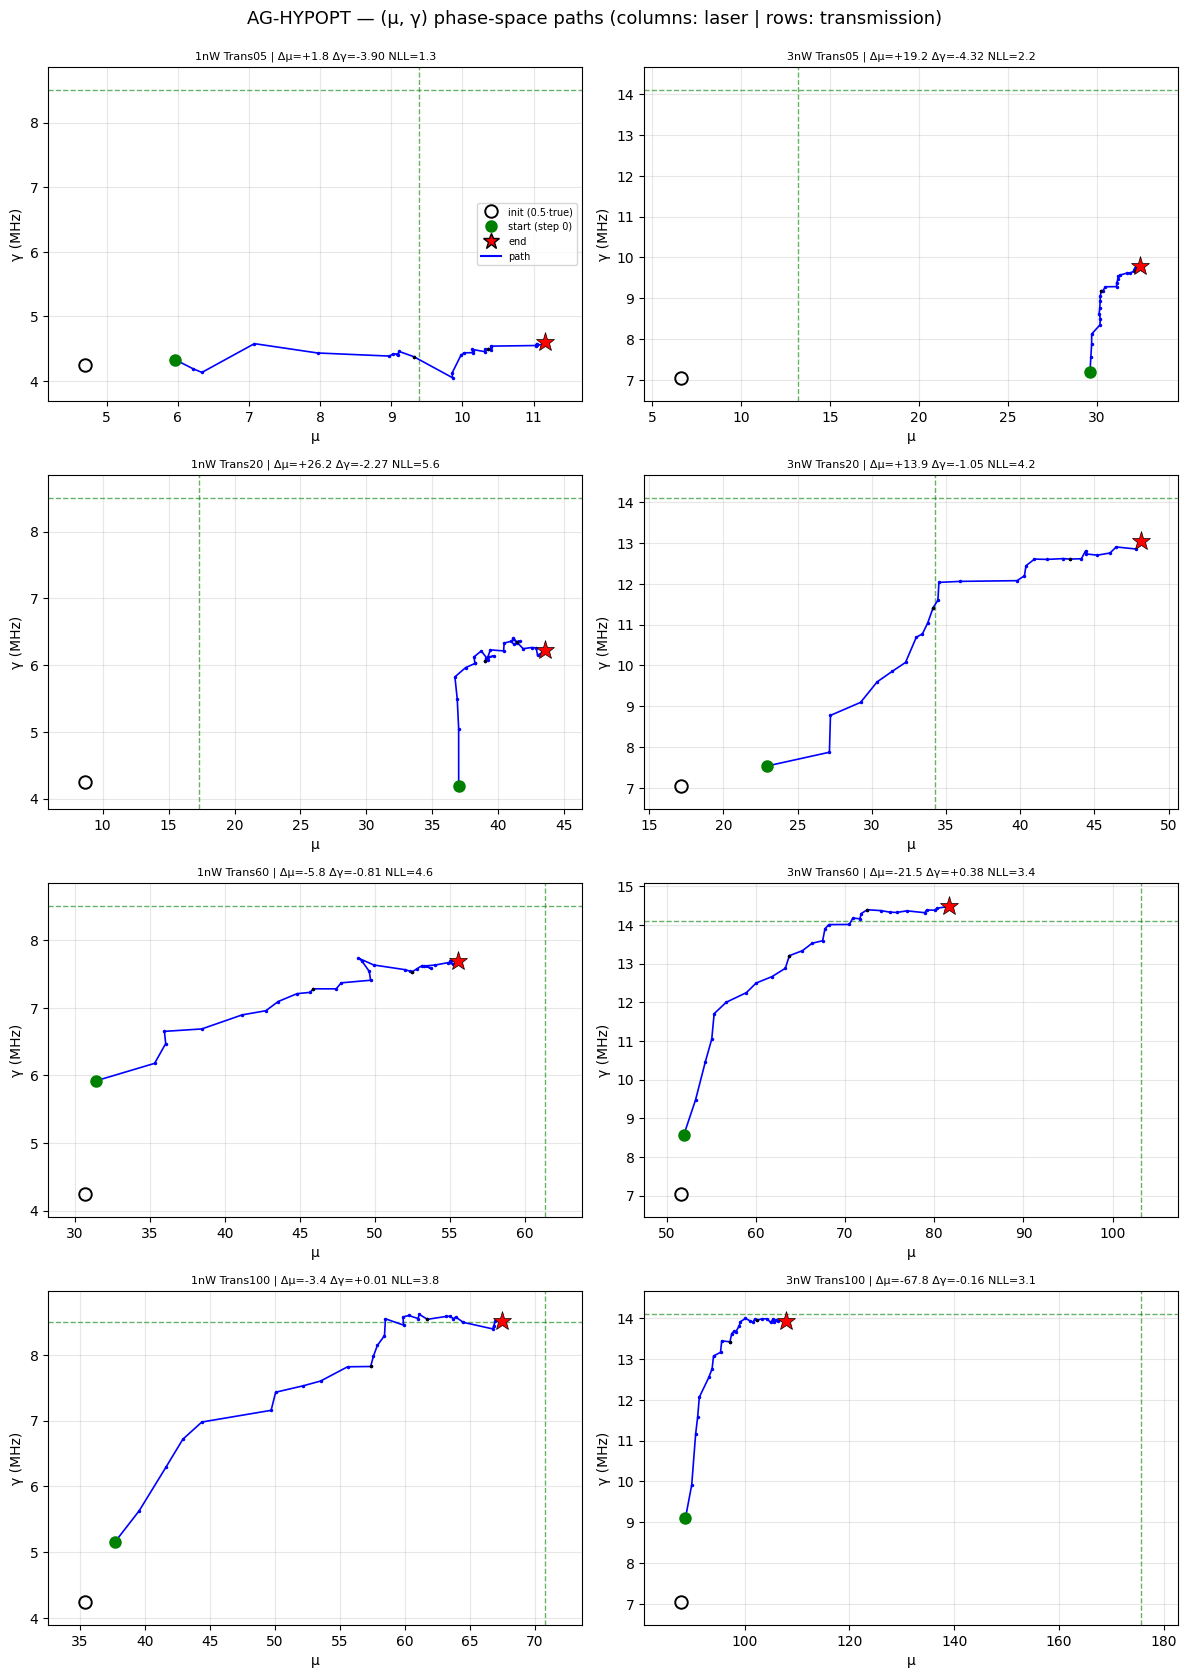

trial finished in 8.8 min
objective = 0.1127 ± 0.0822
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   11.16   +18.8 |     8.50    4.60   -45.9
1nW Trans20       17.32   43.56  +151.6 |     8.50    6.23   -26.7
1nW Trans60       61.37   55.55    -9.5 |     8.50    7.69    -9.5
1nW Trans100       70.82   67.47    -4.7 |     8.50    8.51    +0.1
3nW Trans05       13.20   32.41  +145.5 |    14.10    9.78   -30.6
3nW Trans20       34.28   48.16   +40.5 |    14.10   13.05    -7.4
3nW Trans60      103.20   81.69   -20.8 |    14.10   14.48    +2.7
3nW Trans100      175.71  107.95   -38.6 |    14.10   13.94    -1.2

weighted objective (T-graded, cap=1.0) = 0.1127 | diverged cells: 0
μ: RMSE 28.180 (rel 77.6%, bias -4.668) | γ: RMSE 2.264 (rel 22.1%, bias -1.517)


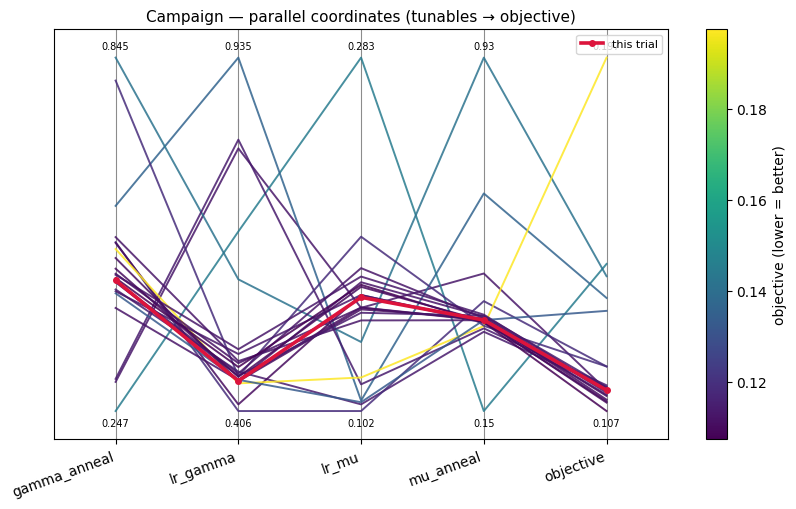

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 23 ran the highest-EI candidate (candidate 4, ei=3.96): `lr_mu=0.1605`, `mu_anneal=0.3508` (effective mu travel 0.132), `lr_gamma=0.4509`, `gamma_anneal=0.4684`. It completed in 8.8 min with objective **0.1127 +/- 0.0822** and **0 diverged cells** — mid-plateau. Ranking: trial_21 0.1074 < trial_22 0.1095 < trial_08 0.1099 < trial_15 0.1103 < trial_16 0.1112 < trial_12 0.1115 < trial_18 0.1121 < trial_09 = trial_20 0.1126 < trial_01 = trial_14 = **trial_23 0.1127** < ...

Aggregate accuracy: **mu rel-RMSE 77.6%** (RMSE 28.18, bias -4.67); **gamma rel-RMSE 22.1%** (RMSE 2.26, bias -1.52).

Per-cell relative errors:
- **mu:** 1nW T05 +18.8%, T20 +151.6%, T60 -9.5%, T100 -4.7% | 3nW T05 +145.5%, T20 +40.5%, T60 -20.8%, T100 -38.6%.
- **gamma:** 1nW T05 -45.9%, T20 -26.7%, T60 -9.5%, T100 +0.1% | 3nW T05 -30.6%, T20 -7.4%, T60 +2.7%, T100 -1.2%.

This was the closest possible test — its config is almost trial_21 with slightly lower mu travel (0.132 vs 0.138) — and it landed mid-plateau at 0.1127. The key difference from the two best runs is the 1nW T60 mu cell (-9.5% here vs trial_21's -2.9% and trial_22's -5.8%). So the best region is genuinely narrow: the objective improves steadily as travel moves from 0.132 (0.1127) to 0.137-0.138 (0.1095 / **0.1074**), i.e. the optimum sits tightly at travel ~0.137-0.138 with balanced gamma knobs. trial_21 (0.1074) remains the best.

**Summary:** Trial 23 (lr_mu=0.1605, mu_anneal=0.3508, lr_gamma=0.4509, gamma_anneal=0.4684): objective 0.1127 +/- 0.0822 with 0 diverged cells; a near-neighbour of the best (travel 0.132) landed mid-plateau, so trial_21's 0.1074 stands as best.
**Key insight:** The best region is narrow: trial_21 (travel 0.138) and trial_22 (0.137) beat trial_23 (0.132), placing the optimum tightly at travel ~0.137-0.138 with balanced gamma knobs (lr_gamma ~ gamma_anneal ~ 0.47).

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The difference between 0.1074 and 0.1127 is concentrated in a couple of small cells (1nW T60), so the optimum is a narrow spike rather than a broad basin. Further samples should stay within travel ~0.136-0.139 with `lr_gamma` ~ `gamma_anneal` ~ 0.46-0.49. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 23 (lr_mu=0.1605, mu_anneal=0.3508, lr_gamma=0.4509, gamma_anneal=0.4684): objective 0.1127 +/- 0.0822 with 0 diverged cells; a near-neighbour of the best (travel 0.132) landed mid-plateau, so trial_21's 0.1074 stands as best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The best region is narrow: trial_21 (travel 0.138) and trial_22 (0.137) beat trial_23 (0.132), placing the optimum tightly at travel ~0.137-0.138 with balanced gamma knobs (lr_gamma ~ gamma_anneal ~ 0.47)"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_23 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_24.ipynb. Open it and follow its cells from the top.
